In [1]:
from numpy.f2py.rules import aux_rules
#from mca_shared_izzy.mca_shared_si_conc import dot_xa_masked
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re
import sys
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import os
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')

In [3]:
# constant
rho_a = 1.25 # air density kg m-3
cd_aw = 1.25e-3 # drag coeff
rho_w = 1028
cd_iw = 5.5e-3

In [4]:
import netCDF4
import h5netcdf

In [5]:
# #downloading SI_drift data noaa
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V5/south/monthly/"
#
# r = requests.get(archive_url)
#
# data = BeautifulSoup(r.text, "html.parser")
#
# for l in data.find_all("a")[1:]:
# 	r = requests.get(archive_url + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r.content)

In [6]:
# #downloading SI_conc data noaa
# archive_url_conc = "https://noaadata.apps.nsidc.org/NOAA/G02202_V4/south/monthly/"
#
# r_conc = requests.get(archive_url_conc)
#
# data_conc = BeautifulSoup(r_conc.text, "html.parser")
#
# for l in data_conc.find_all("a")[1:]:
# 	r_conc = requests.get(archive_url_conc + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r_conc.content)

In [7]:
# dot dataset
# path = '/Users/iw2g24/PycharmProjects/SSH_project/'
# print(path)
# ds = xr.open_dataset(path + 'Data/dot_all_30bmedian_goco05c_sig3_1.nc')
# print(ds)
# # ERA5 remap dataset
# ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')

path = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
save_dir = path + 'Oana/test_figs/'
aux_scripts = path + 'Scripts/aux_scripts/'
print(path)

workdir = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = workdir + 'Data/'
mca_dir = data_dir + 'mca_processing/'
clim_dir = data_dir + 'climate_indices/'
script_dir = workdir + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'
fig_dir = workdir + 'Figures/'
scores_comps_dir = mca_dir + 'scores_comps/'


sys.path.append(aux_scripts)
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D

dot_ds = xr.open_dataset(path + 'Data/Oana/original_fully_processed_oana_ds/dot_all_30bmedian_goco05c_sig3_1.nc')

# dot_ds = xr.open_dataset('/Users/iw2g24/PycharmProjects/SLA_analysis/Data/dot_all_30bmedian_egm2008_sig3.nc')
# bad_month_mask = dot_ds['bad_month_flag'].values   # shape (270,)
# dot_ds = dot_ds.isel(time=~bad_month_mask)
# # dot_ds = dot_ds.sel(time=slice('2002-11-01', '2018-12-01'))

print(dot_ds)
# ERA5 remap dataset
# ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')
era5_ds = xr.open_dataset(path + 'Data/ERA5/era5_regridded_2002_2024_monthly.nc')

# sic_ds = xr.open_dataset(path + 'Data/NOAA_SIC_monthly/sic_regridded_2002_2024_monthly.nc')
# sid_ds  = xr.open_dataset(path + 'Data/NASA_SID_weekly/sid_regridded_2002_2024_monthly.nc')

sic_ds = xr.open_dataset(path + 'Data/NOAA_SIC_monthly/noaa_sic_2025_corrected.nc')
sid_ds  = xr.open_dataset(path + 'Data/NASA_SID_weekly/nasa_sid_2025_corrected.nc')


/Users/iw2g24/PycharmProjects/SLA_analysis/
<xarray.Dataset> Size: 109MB
Dimensions:          (longitude: 360, latitude: 64, time: 196, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 36MB ...
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry

In [8]:
# # change coordinates from (lon,lat,time) to (time,lat,lon) as ERA5
# lon = ds['longitude'].values; lat = ds['latitude'].values
# # dot_all = ds['dot'].values
# # dot = np.zeros((dot_all.shape[2], dot_all.shape[1], (dot_all.shape[0])))
# # for t in range(0,dot_all.shape[2]):
# #     for i in range(0,dot_all.shape[1]):
# #         for j in range(0,dot_all.shape[0]):
# #             dot[t,i,j] = dot_all[j,i,t].copy()
# # seamask = dot[0].copy()/dot[0]
# # seamask[seamask == 0] = np.nan
# # del dot_all
#
# # change coordinates from (lon,lat,time) to (time,lat,lon)
# dot_all = ds['dot'].values
# dot = dot_all.transpose(2, 1, 0)
# dot[bad_month_mask] = np.nan
#



In [9]:
dot = dot_ds.dot.values
lon = dot_ds.longitude.values
lat = dot_ds.latitude.values
dot_time = dot_ds.time.values
print(dot_ds.dot.shape)
# seamask
seamask = dot[:,:,0] / dot[:,:,0]
seamask[seamask == 0] = np.nan

era5_ds = era5_ds.sel(time=dot_time)
sic_ds = sic_ds.sel(time=dot_time)
sid_ds = sid_ds.sel(time=dot_time)


(360, 64, 196)


In [10]:
llon, llat = np.meshgrid(lon, lat, indexing='ij')

# # make lon lat 2d
# llon = np.zeros((dot.shape[0],dot.shape[2]))
# for i in range(0,dot.shape[1]):
#     llon[i,:] = lon
# llat = np.zeros((dot.shape[1],dot.shape[2]))
# for i in range(0,dot.shape[2]):
#     llat[:,i] = lat

In [11]:
print(dot.shape)
print(era5_ds.u10.shape)

(360, 64, 196)
(360, 64, 196)


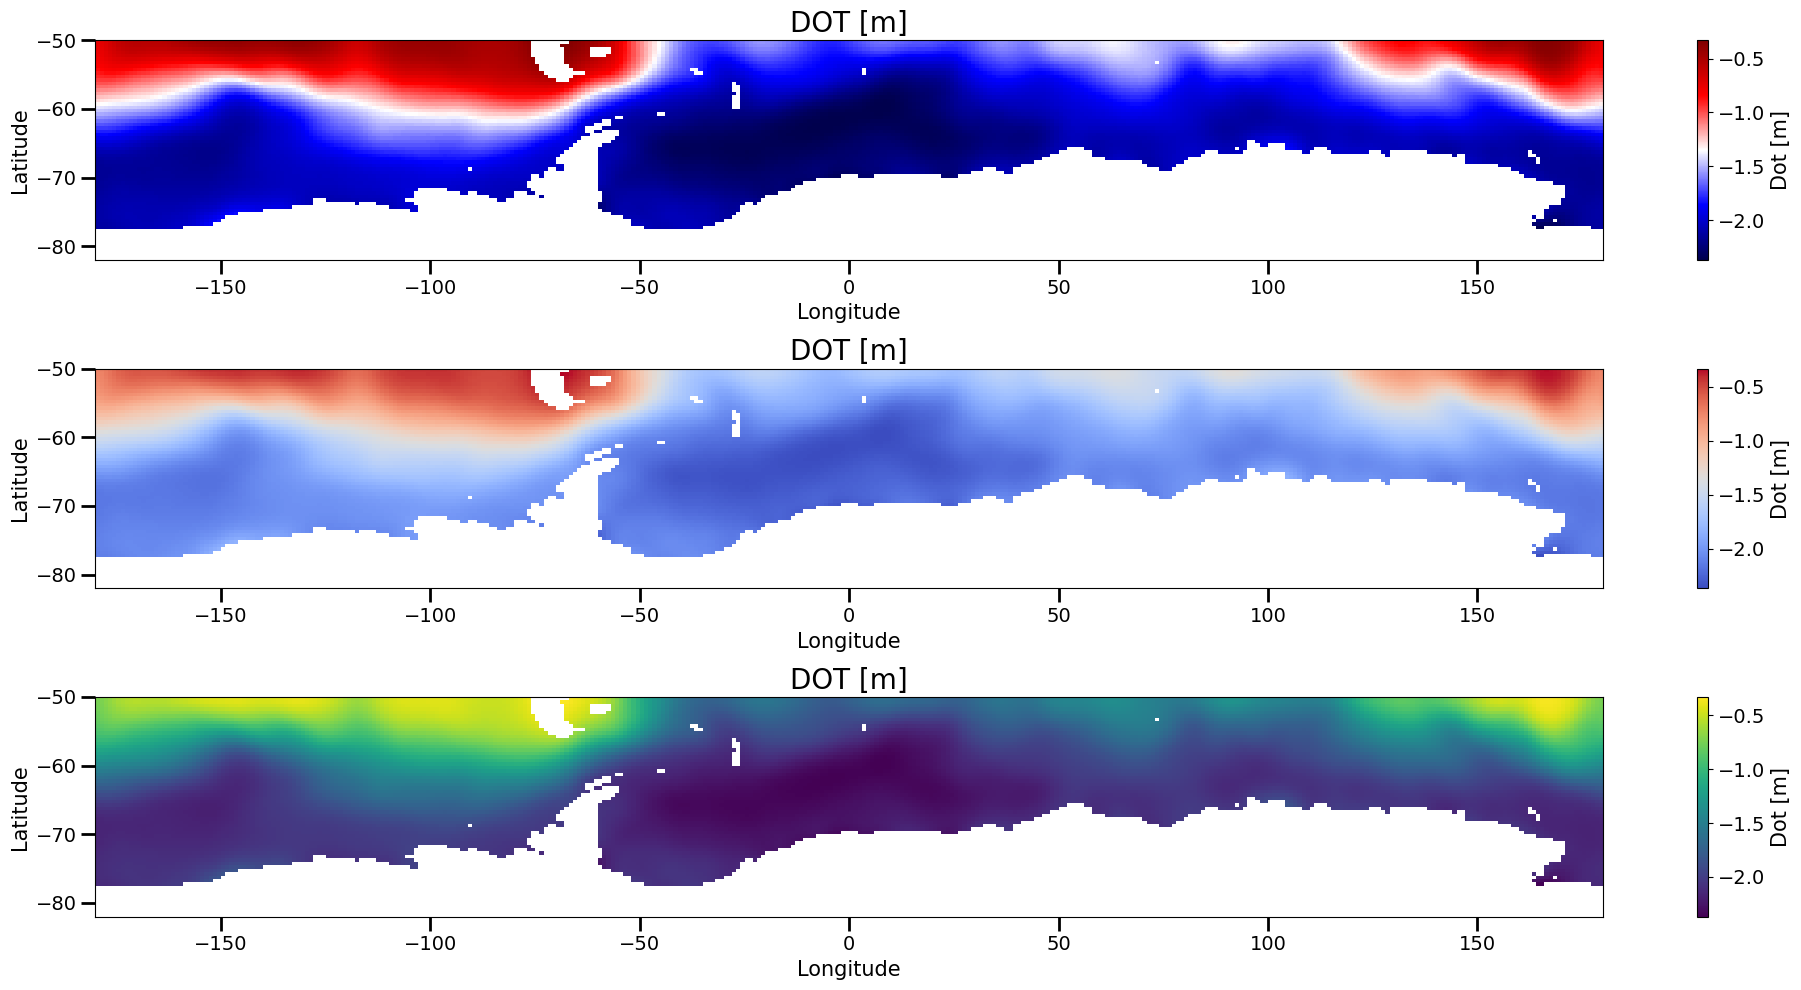

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

pc1 = axes[0].pcolormesh(llon,llat,dot[:,:,0], cmap='seismic')
axes[0].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[0].set_title('DOT [m]', fontsize=20)
axes[0].set_xlabel('Longitude', fontsize=15)
axes[0].set_ylabel('Latitude', fontsize=15)
cbar1 = fig.colorbar(pc1, ax=axes[0])
cbar1.set_label('Dot [m]', fontsize=15)
cbar1.ax.tick_params(labelsize=14)

pc2 = axes[1].pcolormesh(llon,llat,dot[:,:,0], cmap='coolwarm')
axes[1].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[1].set_title('DOT [m]', fontsize=20)
axes[1].set_xlabel('Longitude', fontsize=15)
axes[1].set_ylabel('Latitude', fontsize=15)
cbar2 = fig.colorbar(pc2, ax=axes[1])
cbar2.set_label('Dot [m]', fontsize=15)
cbar2.ax.tick_params(labelsize=14)

pc3 = axes[2].pcolormesh(llon,llat,dot[:,:,0], cmap='viridis')
axes[2].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[2].set_title('DOT [m]', fontsize=20)
axes[2].set_xlabel('Longitude', fontsize=15)
axes[2].set_ylabel('Latitude', fontsize=15)
cbar3 = fig.colorbar(pc3, ax=axes[2])
cbar3.set_label('Dot [m]', fontsize=15)
cbar3.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

In [13]:
# total_nans = dot_xa.isnull().sum().item()
# print(f"Total NaN values in dot_xa: {total_nans}")


In [14]:
# select wind
u10 = era5_ds['u10'].values
v10 = era5_ds['v10'].values

# print(era5_ds.u10.shape)
# print(u10.shape)
# # map lat in lat[::-1] when using gridboxmean mapping
# # since lat in ERA5 goes from -50 to -80 instead in dot goes from -80 to -50
# if gridtype == 'gridboxmean':
#     print('you are using ',gridtype)
#     u10 = u10[:,::1,:]
#     v10 = v10[:,::1,:]

print(seamask.shape)

u10 = u10*seamask[:,:, None]
v10 = v10*seamask[:,:, None]
U_air = np.sqrt(u10**2. + v10**2.)

print(u10.shape)

(360, 64)
(360, 64, 196)


In [15]:
# wind stress
tau_x = rho_a*cd_aw*U_air*u10 #zonal wind
tau_y = rho_a*cd_aw*U_air*v10 #meridional wind

print('zonal wind:',  tau_x.shape)
print('meridional wind:', tau_y.shape)

zonal wind: (360, 64, 196)
meridional wind: (360, 64, 196)


In [64]:
# ocean surface stress
alpha = sic_ds['cdr_seaice_conc_monthly'].values
u_ice = sid_ds.u_rotated.values * 1e-2
v_ice = sid_ds.v_rotated.values *1e-2


"""
THIS IS TESTING NANS = 0
"""

# # change Nan locations to 0 as this means there is no ice data which is either no SIC or drift
alpha   = np.nan_to_num(alpha,   nan=0.0)   # no ice = 0 concentration
u_ice   = np.nan_to_num(u_ice,   nan=0.0)   # no ice = no ice velocity
v_ice   = np.nan_to_num(v_ice,   nan=0.0)

"""
END OF TEST
"""

U_ice_mag = np.sqrt(u_ice**2. + v_ice**2.)

#ice-water stress
tau_iw_x = rho_w *cd_iw *U_ice_mag *u_ice
tau_iw_y = rho_w *cd_iw *U_ice_mag *v_ice

#air-water stress
tau_aw_x = rho_a * cd_aw * U_air * u10
tau_aw_y = rho_a * cd_aw * U_air * v10

#total oss
oss_x = alpha * tau_iw_x + (1 - alpha) * tau_aw_x
oss_y = alpha * tau_iw_y + (1 - alpha) * tau_aw_y

oss_mag = np.sqrt(oss_x**2. + oss_y**2.)


In [65]:
print(np.nanmax(u_ice))
print(np.nanmax(v_ice))
print(np.nanmax(alpha))


print(oss_mag.shape)
print(tau_x.shape)

print(llat.min(), llat.max())   # should be ~ -82 to -50 (latitude range)
print(llon.min(), llon.max())   # should be ~ -180 to 180 (longitude range)

0.32820438089221526
0.23702086401619218
1.0
(360, 64, 196)
(360, 64, 196)
-81.75 -50.25
-179.5 179.5


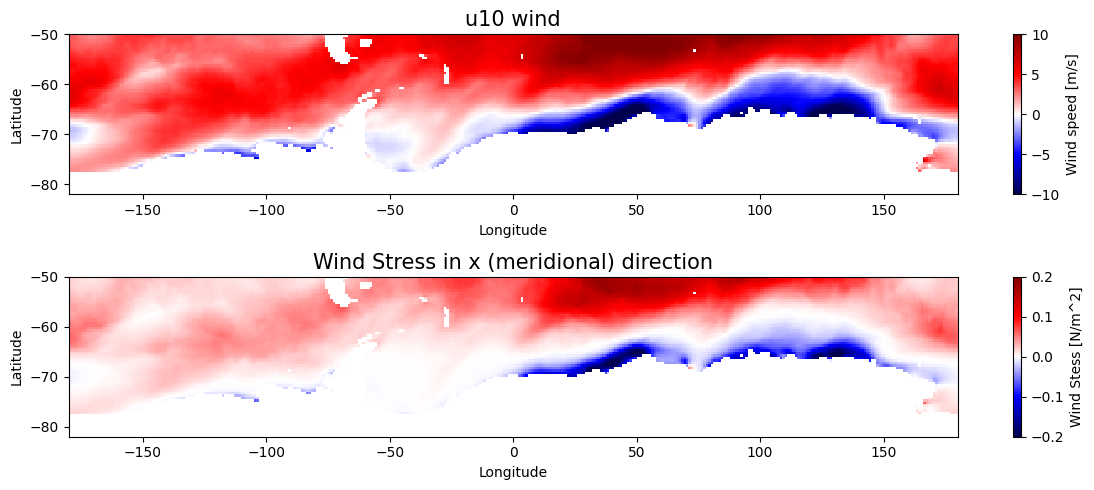

In [66]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon, llat, u10[:,:,0],cmap='seismic',vmin=-10,vmax=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('u10 wind', fontsize=15)
cbar1= plt.colorbar()
cbar1.set_label('Wind speed [m/s]')
plt.subplot(2,1,2)
plt.pcolormesh(llon, llat,tau_x[:,:,0],cmap='seismic',vmin=-0.2,vmax=0.2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress in x (meridional) direction', fontsize=15)
cbar2= plt.colorbar()
cbar2.set_label('Wind Stess [N/m^2]')


plt.tight_layout()


In [67]:
print(tau_x.shape)
print(tau_y.shape)
print(llon.shape)
print(llat.shape)
print(dot.shape)
print(oss_mag.shape)

(360, 64, 196)
(360, 64, 196)
(360, 64)
(360, 64)
(360, 64, 196)
(360, 64, 196)


In [68]:
ws_curl = np.zeros_like(tau_x)
for t in range(dot.shape[2]):
    # transpose to (lat, lon) for grad_sphere, then transpose result back
    dtaux_dx, dtaux_dy = grad_sphere(tau_x[:,:,t].T, llon.T, llat.T)
    dtauy_dx, dtauy_dy = grad_sphere(tau_y[:,:,t].T, llon.T, llat.T)
    ws_curl[:,:,t] = (dtauy_dx - dtaux_dy).T

ws_curl[~np.isfinite(ws_curl)] = np.nan

In [69]:
# ocean stress curl
# os_curl = np.zeros_like(oss_x)
# for t in range(dot.shape[2]):
#     dtaux_dx, dtaux_dy = grad_sphere( oss_x[:,:,t], llon, llat)
#     dtauy_dx, dtauy_dy = grad_sphere( oss_y[:,:,t], llon, llat)
#     os_curl[:,:,t] = dtauy_dx - dtaux_dy
#     os_curl[np.isinf(os_curl)] = np.nan

os_curl = np.zeros_like(oss_x)
for t in range(dot.shape[2]):
    dtaux_dx, dtaux_dy = grad_sphere(oss_x[:,:,t].T, llon.T, llat.T)
    dtauy_dx, dtauy_dy = grad_sphere(oss_y[:,:,t].T, llon.T, llat.T)
    os_curl[:,:,t] = (dtauy_dx - dtaux_dy).T

os_curl[~np.isfinite(os_curl)] = np.nan

In [70]:
# Where are the extra NaNs in osc that aren't in wsc?
wsc_nan_mask = np.isnan(ws_curl[:, :, 0])
osc_nan_mask = np.isnan(os_curl[:, :, 0])

extra_nans = osc_nan_mask & ~wsc_nan_mask
print(f"Extra NaN points in osc not in wsc: {extra_nans.sum()}")

# Which variable is causing them?
print(f"NaNs in alpha t=0:  {np.isnan(alpha[:, :, 0]).sum()}")
print(f"NaNs in u_ice t=0:  {np.isnan(u_ice[:, :, 0]).sum()}")
print(f"NaNs in v_ice t=0:  {np.isnan(v_ice[:, :, 0]).sum()}")
print(f"NaNs in u10 t=0:    {np.isnan(u10[:, :, 0]).sum()}")
print(f"NaNs in v10 t=0:    {np.isnan(v10[:, :, 0]).sum()}")

Extra NaN points in osc not in wsc: 0
NaNs in alpha t=0:  0
NaNs in u_ice t=0:  0
NaNs in v_ice t=0:  0
NaNs in u10 t=0:    8073
NaNs in v10 t=0:    8073


In [71]:
print(np.isnan(ws_curl[:,:,0]).sum(), "NaNs")
print(np.isinf(ws_curl[:,:,0]).sum(), "Infs")
print(np.nanmin(ws_curl[:,:,0]), np.nanmax(ws_curl[:,:,0]))
print(np.isnan(os_curl[:,:,0]).sum(), "NaNs")
print(np.isinf(os_curl[:,:,0]).sum(), "Infs")
print(np.nanmin(os_curl[:,:,1]),np.nanmax(os_curl[:,:,0]))
print(np.isnan(tau_x[:,:,0]).sum(), "NaNs in tau_x")
print(np.isnan(tau_y[:,:,0]).sum(), "NaNs in tau_y")


print(np.isinf(ws_curl).sum(), "Infs in ws_curl")   # should be 0
print(np.isinf(os_curl).sum(), "Infs in os_curl")   # should be 0
print(np.isnan(ws_curl[:,:,0]).sum(), "NaNs in ws_curl t=0")
print(np.isnan(os_curl[:,:,0]).sum(), "NaNs in os_curl t=0")

8641 NaNs
0 Infs
-1.7550045910229912e-06 1.2240370096574767e-06
8641 NaNs
0 Infs
-1.1079995361550363e-06 9.697511815039017e-07
8073 NaNs in tau_x
8073 NaNs in tau_y
0 Infs in ws_curl
0 Infs in os_curl
8641 NaNs in ws_curl t=0
8641 NaNs in os_curl t=0


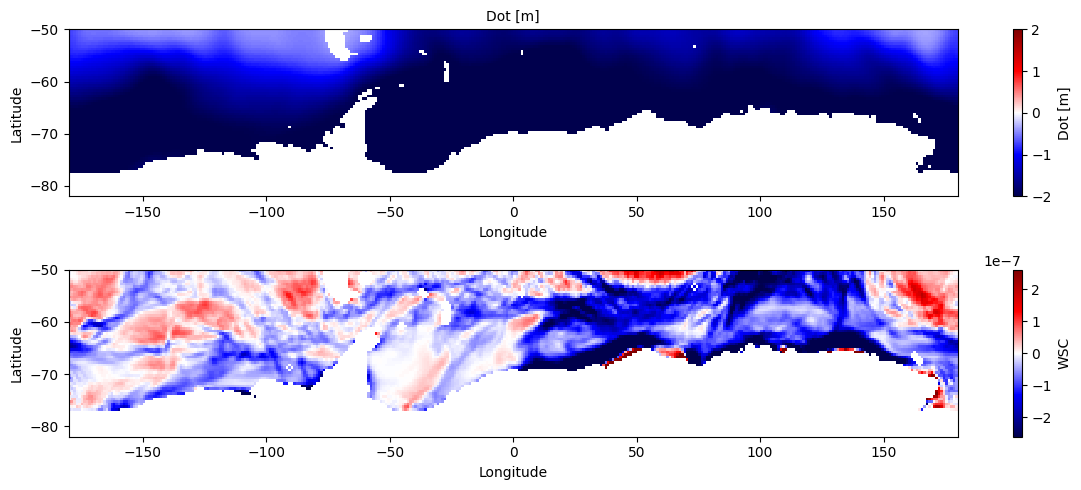

In [72]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon, llat, dot[:,:,0], vmin=-2, vmax=2, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Dot [m]', fontsize=10)
ws1bar = plt.colorbar()
ws1bar.set_label('Dot [m]')

vlim = np.nanpercentile(np.abs(ws_curl[:,:,0]), 95)  # robust to outliers
plt.subplot(2,1,2)
plt.pcolormesh(llon, llat, ws_curl[:,:,0], vmin=-vlim, vmax=vlim, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.quiver(llon, llat, u10[0], v10[0])
ws2bar = plt.colorbar()
ws2bar.set_label('WSC')

plt.tight_layout()

In [73]:
# DE-TREND
dot.shape

(360, 64, 196)

In [74]:
dot_transposed = dot.transpose(2, 0, 1)  # (time, lon, lat)
n, slope, intercept, p_val, r_square, rmse = linregress_3D(dot_transposed)
# slope, intercept are (lon, lat)

t_index = np.arange(1, dot_transposed.shape[0] + 1)  # matches x_array in function
dot_detrended = dot_transposed - (slope[np.newaxis, :, :] * t_index[:, np.newaxis, np.newaxis] + intercept[np.newaxis, :, :])

dot_detrended = dot_detrended.transpose(1, 2, 0)  # back to (lon, lat, time)

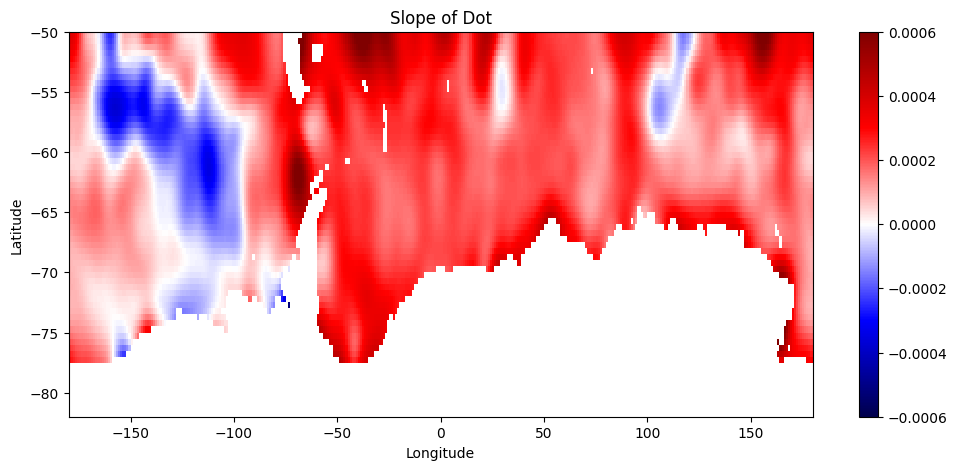

In [75]:
plt.figure(figsize=(12,5))
plt.pcolormesh(llon, llat, slope, vmin=-6e-4, vmax=6e-4, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Slope of Dot')
plt.colorbar()


In [76]:
wsc_transposed = ws_curl.transpose(2, 0, 1)  # (time, lon, lat)
n, slope, intercept, p_val, r_square, rmse = linregress_3D(wsc_transposed)
# slope, intercept are (lon, lat)

t_index = np.arange(1, wsc_transposed.shape[0] + 1)  # matches x_array in function
wsc_detrended = wsc_transposed - (slope[np.newaxis, :, :] * t_index[:, np.newaxis, np.newaxis] + intercept[np.newaxis, :, :])

wsc_detrended = wsc_detrended.transpose(1, 2, 0)  # back to (lon, lat, time)

In [77]:
osc_transposed = os_curl.transpose(2, 0, 1)  # (time, lon, lat)
n, slope, intercept, p_val, r_square, rmse = linregress_3D(osc_transposed)
# slope, intercept are (lon, lat)

t_index = np.arange(1, osc_transposed.shape[0] + 1)  # matches x_array in function
osc_detrended = osc_transposed - (slope[np.newaxis, :, :] * t_index[:, np.newaxis, np.newaxis] + intercept[np.newaxis, :, :])

osc_detrended = osc_detrended.transpose(1, 2, 0)  # back to (lon, lat, time)

In [78]:
# DE-SEASONAL

In [79]:
months = (dot_time.astype('datetime64[M]').astype(int) % 12 + 1)
print(months)

[ 7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10]


In [80]:

print("dot:", dot_detrended.shape)
print("ws:", wsc_detrended.shape)
print("months:", months.shape)


dot: (360, 64, 196)
ws: (360, 64, 196)
months: (196,)


In [81]:
remove_seas = False  # set this at the top of your script

if remove_seas:
    # Preallocate seasonal arrays
    dot_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)
    wsc_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)
    osc_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)

    # Compute monthly climatology
    for m in range(1, 13):
        mask = (months == m)
        if np.any(mask):
            dot_seas[m-1] = np.nanmean(dot_detrended[:,:,mask], axis=2)
            wsc_seas[m-1] = np.nanmean(wsc_detrended[:,:,mask], axis=2)
            osc_seas[m-1] = np.nanmean(osc_detrended[:,:,mask], axis=2)

    # Remove seasonality
    dot_final = np.zeros_like(dot_detrended)
    wsc_final = np.zeros_like(wsc_detrended)
    osc_final = np.zeros_like(osc_detrended)
    for i, m in enumerate(months):
        dot_final[:,:,i] = dot_detrended[:,:,i] - dot_seas[m-1]
        wsc_final[:,:,i] = wsc_detrended[:,:,i] - wsc_seas[m-1]
        osc_final[:,:,i] = osc_detrended[:,:,i] - osc_seas[m-1]

    print("Seasonal cycle removed.")

else:
    dot_final = dot_detrended.copy()
    wsc_final = wsc_detrended.copy()
    osc_final = osc_detrended.copy()

    print("Seasonal cycle retained.")


Seasonal cycle retained.


In [82]:
print(dot.shape)
print(dot_final.shape)
print(ws_curl.shape)
print(wsc_final.shape)
print(os_curl.shape)
print(osc_final.shape)


# print(dot[1])
# print(dot[2])

(360, 64, 196)
(360, 64, 196)
(360, 64, 196)
(360, 64, 196)
(360, 64, 196)
(360, 64, 196)


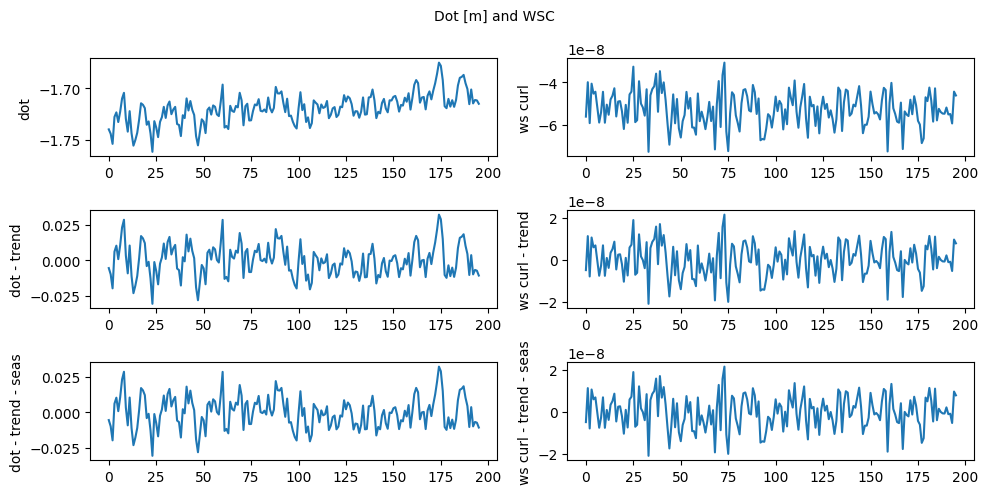

In [83]:
fig = plt.figure(figsize=(10,5))
plt.subplot(3,2,1)
plt.plot(np.nanmean(dot, axis=(0,1)))
plt.ylabel('dot')
plt.subplot(3,2,2)
plt.plot(np.nanmean(ws_curl, axis=(0,1)))
plt.ylabel('ws curl')
plt.subplot(3,2,3)
plt.plot(np.nanmean(dot_detrended, axis=(0,1)))
plt.ylabel('dot - trend')
plt.subplot(3,2,4)
plt.plot(np.nanmean(wsc_detrended, axis=(0,1)))
plt.ylabel('ws curl - trend')
plt.subplot(3,2,5)
plt.plot(np.nanmean(dot_final, axis=(0,1)))
plt.ylabel('dot - trend - seas')
plt.subplot(3,2,6)
plt.plot(np.nanmean(wsc_final, axis=(0,1)))
plt.ylabel('ws curl - trend - seas')
plt.suptitle('Dot [m] and WSC', fontsize=10)

plt.tight_layout()

In [84]:
print(dot_final.shape)

(360, 64, 196)


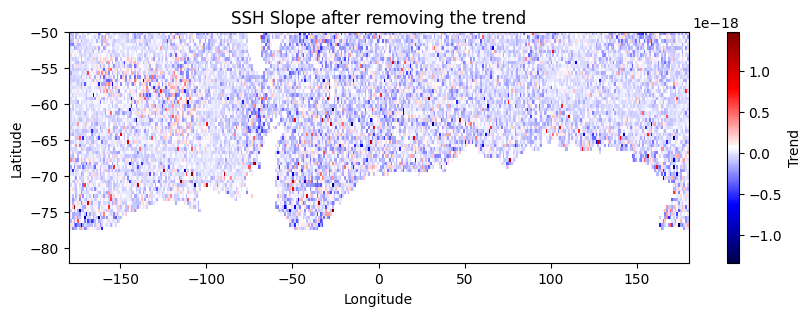

In [85]:
# SSH trends without removing ocean variability due to wind stress curl
plt.figure(figsize=(10,3))
n, slope, intercept, p_val, r_square, rmse = linregress_3D(dot_detrended.transpose(2, 0, 1))
plt.pcolormesh(lon, lat, slope.T, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SSH Slope after removing the trend')
cbar = plt.colorbar()
cbar.set_label('Trend')

In [86]:
# MCA

In [87]:
# dot[bad_month_mask[0:-13]] = np.nan
# ws_curl[bad_month_mask[0:-13]] = np.nan
# dot = dot * seamask
# ws_curl = ws_curl * seamask
#
# joint_mask = ~np.isnan(dot) & ~np.isnan(ws_curl)
# joint_mask = np.all(joint_mask, axis=0)   # collapse time → (lat, lon)
#
# dot = dot[:, joint_mask]
# ws_curl = ws_curl[:, joint_mask]
#
# # dot_xa = xr.DataArray(dot, dims=("time", "feature"))
# # ws_curl_xa = xr.DataArray(ws_curl, dims=("time", "feature"))
# #
#
# dot_xa = xr.DataArray(dot_final, coords=[time_dot, lat, lon], dims=["time", "lon", "lat"],)
# ws_curl_xa = xr.DataArray(ws_curl_final, coords=[time_dot, lat, lon], dims=["time", "lon", "lat"],)

In [88]:
# good_time = ~bad_month_mask[:-13]   # align with dot/era window if needed
#
# dot_final = dot_final[good_time]
# ws_curl_final = ws_curl_final[good_time]
# time_dot = time_dot[good_time]
# months   = months[good_time]
#
# joint_mask = ~np.isnan(dot_final) & ~np.isnan(wsc_final)
# joint_mask = np.all(joint_mask, axis=2)  # (lat, lon)
#
# lat2d, lon2d = np.meshgrid(lat, lon, indexing='ij')
# lat_flat = lat2d[joint_mask]
# lon_flat = lon2d[joint_mask]
#
# feature_index = pd.MultiIndex.from_arrays(
#     [lat_flat, lon_flat],
#     names=("lat", "lon")
# )
#
# dot_final = dot_final[:, joint_mask]
# wsc_final = wsc_final[:, joint_mask]
#
# # dot_xa = xr.DataArray(dot, dims=("time", "feature"), coords={"time": time_dot, "feature": np.arange(dot.shape[1])})
# # ws_curl_xa = xr.DataArray(ws_curl, dims=("time", "feature"), coords={"time": time_dot, "feature": np.arange(ws_curl.shape[1])})
#
# dot_xa = xr.DataArray(
#     dot,
#     dims=("time", "feature"),
#     coords={"time": dot_time, "feature": feature_index}
# )
#
# wsc_xa = xr.DataArray(
#     wsc_final,
#     dims=("time", "feature"),
#     coords={"time": dot_time, "feature": feature_index}
# )

dot_xa = xr.DataArray(
    dot_final.transpose(2, 1, 0),          # (time, lat, lon)
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'dot'
)

wsc_xa = xr.DataArray(
    wsc_final.transpose(2, 1, 0),          # (time, lat, lon)
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'wsc'
)

osc_xa = xr.DataArray(
    osc_final.transpose(2,1,0),
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'osc'
)

sla_xa = xr.DataArray(dot_xa - dot_xa.mean(dim = 'time'), name = 'sla')

In [89]:
total_nans = dot_xa.isnull().sum().item()
print(f"Total NaN values in dot_xa: {total_nans}")

total_nans_wsc = wsc_xa.isnull().sum().item()
print(f"Total NaN values in wsc: {total_nans_wsc}")

total_nans_osc = osc_xa.isnull().sum().item()
print(f"Total NaN values in osc: {total_nans_osc}")

total_nans_sla = sla_xa.isnull().sum().item()
print(f"Total NaN values in sla: {total_nans_sla}")

total_points_dot = dot_xa.size
print(f"Total data points in dot_xa: {total_points_dot}")

total_points_wsc = wsc_xa.size
print(f"Total data points in wsc: {total_points_wsc}")

total_points_osc = osc_xa.size
print(f"Total data points in osc_xa: {total_points_osc}")

total_points_sla = sla_xa.size
print(f"Total data points in sla_xa: {total_points_sla}")

Total NaN values in dot_xa: 1582308
Total NaN values in wsc: 1693636
Total NaN values in osc: 1693636
Total NaN values in sla: 1582308
Total data points in dot_xa: 4515840
Total data points in wsc: 4515840
Total data points in osc_xa: 4515840
Total data points in sla_xa: 4515840


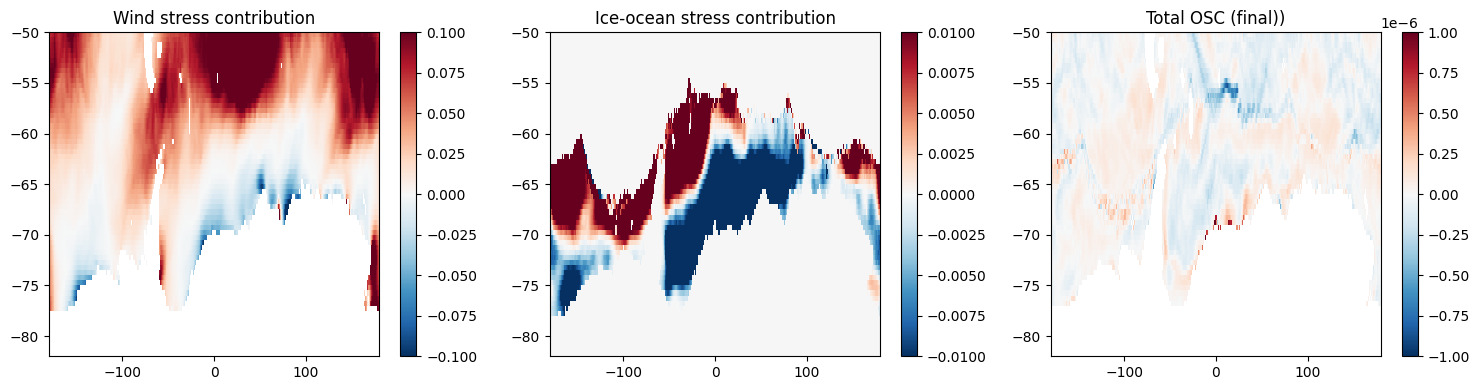

Max ice-ocean stress: 0.31987212908180734
Max wind stress: 0.398503205253155
Ratio: 0.802683955524533


In [94]:
# Plot a single timestep to inspect
t = 50  # pick a summer month
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].pcolormesh(llon, llat, tau_x[:,:,t] + tau_y[:,:,t], cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[0].set_title('Wind stress contribution')
plt.colorbar(im0 , ax =axes[0])

im1 = axes[1].pcolormesh(llon, llat, (tau_iw_x[:,:,t]), cmap='RdBu_r', vmin=-0.01, vmax=0.01)
axes[1].set_title('Ice-ocean stress contribution')
plt.colorbar(im1 , ax =axes[1])

im2 = axes[2].pcolormesh(llon, llat, osc_final[:,:,t], cmap='RdBu_r', vmin=-0.1e-5, vmax=0.1e-5)
axes[2].set_title('Total OSC (final))')
plt.colorbar(im2 , ax =axes[2])

plt.tight_layout()
plt.show()

# Also check the magnitude of ice contribution relative to wind
print("Max ice-ocean stress:", np.nanmax(np.abs(alpha * tau_iw_x)))
print("Max wind stress:", np.nanmax(np.abs(tau_aw_x)))
print("Ratio:", np.nanmax(np.abs(alpha * tau_iw_x)) / np.nanmax(np.abs(tau_aw_x)))

In [95]:
# common_mask = (~dot_xa.isnull()) & (~ws_curl_xa.isnull())
# dot_xa = dot_xa.where(common_mask).dropna(dim=('time','lon','lat'), how='any')
# ws_curl_xa = ws_curl_xa.where(common_mask).dropna(dim=('time','lon','lat'), how='any')

# dot_xa = dot_xa.dropna(dim='lon', how='any')
# dot_xa = dot_xa.dropna(dim='lat', how='any')
#
# ws_curl_xa = ws_curl_xa.dropna(dim='lon', how='any')
# ws_curl_xa = ws_curl_xa.dropna(dim='lat', how='any')



In [96]:
print(dir(xe))


['RotatorFactory', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'base_model', 'cross', 'data_container', 'linalg', 'multi', 'preprocessing', 'rotator_factory', 'single', 'utils', 'validation']


In [98]:
import inspect
model = xe.cross.MCA(n_modes=22, standardize=False)
#print(dir(model))
#
# var_1_name = 'DOT'
# var_2_name = 'OSC'
#
# var_1 = dot_xa
# var_2 = osc_xa

var_1 = sla_xa
var_2 = osc_xa

var_1_name = var_1.name.upper()
var_2_name = var_2.name.upper()

print(dot_xa.coords)

print(dir(model))
print(var_1.dims)
print(var_2.dims)
model.fit(var_1, var_2, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)

Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
  * lat      (lat) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_in

In [99]:
# how many spatial points are fully valid across all timesteps?
valid_1 = (~np.isnan(var_1)).all(dim='time')
valid_2 = (~np.isnan(var_2)).all(dim='time')
valid_both = valid_1 & valid_2

print(f"Valid {var_1} points:", valid_1.sum().item())
print(f"Valid {var_2} points:", valid_2.sum().item())
print("Valid in both:", valid_both.sum().item())  # this is what xeofs sees

# check what grad_sphere actually receives
t = 0
field = tau_x[:,:,t]
print("field shape:", field.shape)
print("llon shape:", llon.shape)
print("llat shape:", llat.shape)
print("llon values sample:", llon[:,0])   # should be -179.5 to 179.5 (longitude)
print("llat values sample:", llat[0,:])   # should be -81.75 to -50.25 (latitude)
print("costheta min:", np.cos(llat * np.pi/180).min())
print("costheta max:", np.cos(llat * np.pi/180).max())

# check lon differences used in df_dx
print("llon col diffs sample:", (llon[:,2:] - llon[:,:-2])[0,:5])  # should be ~2.0

Valid <xarray.DataArray 'sla' (time: 196, lat: 64, lon: 360)> Size: 36MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.01632978,  0.01796447,  0.01840469, ...,  0.00589168,
          0.01019156,  0.0137109 ],
        [ 0.02223085,  0.02473459,  0.02603776, ...,  0.00930763,
          0.01443213,  0.01877383],
        [ 0.02563363,  0.02866541,  0.0304946 , ...,  0.01122258,
          0.01683511,  0.02166971]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         

In [100]:
s1 = scores1.values; s2 = scores2.values
c1 = comps1.values; c2 = comps2.values

In [101]:
# def component_to_map(comp):
#     return comp.unstack("feature")

In [102]:
# print(path)
# print(gridtype)

In [103]:
# Full path to the 'results' directory
results_dir = os.path.join(path, 'Oana/', 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")

Directory already exists


In [104]:
# write PCs on files


# fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(dot_time)):
#         file.write(f'{dot_time[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(dot_time)):
#         file.write(f'{dot_time[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()

In [105]:
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...

In [106]:
r_pears = []; p_pears = []
r_spear = []; p_spear = []
for m in range(1,6):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2)); p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2)); p_spear.append(np.round(p, 2))

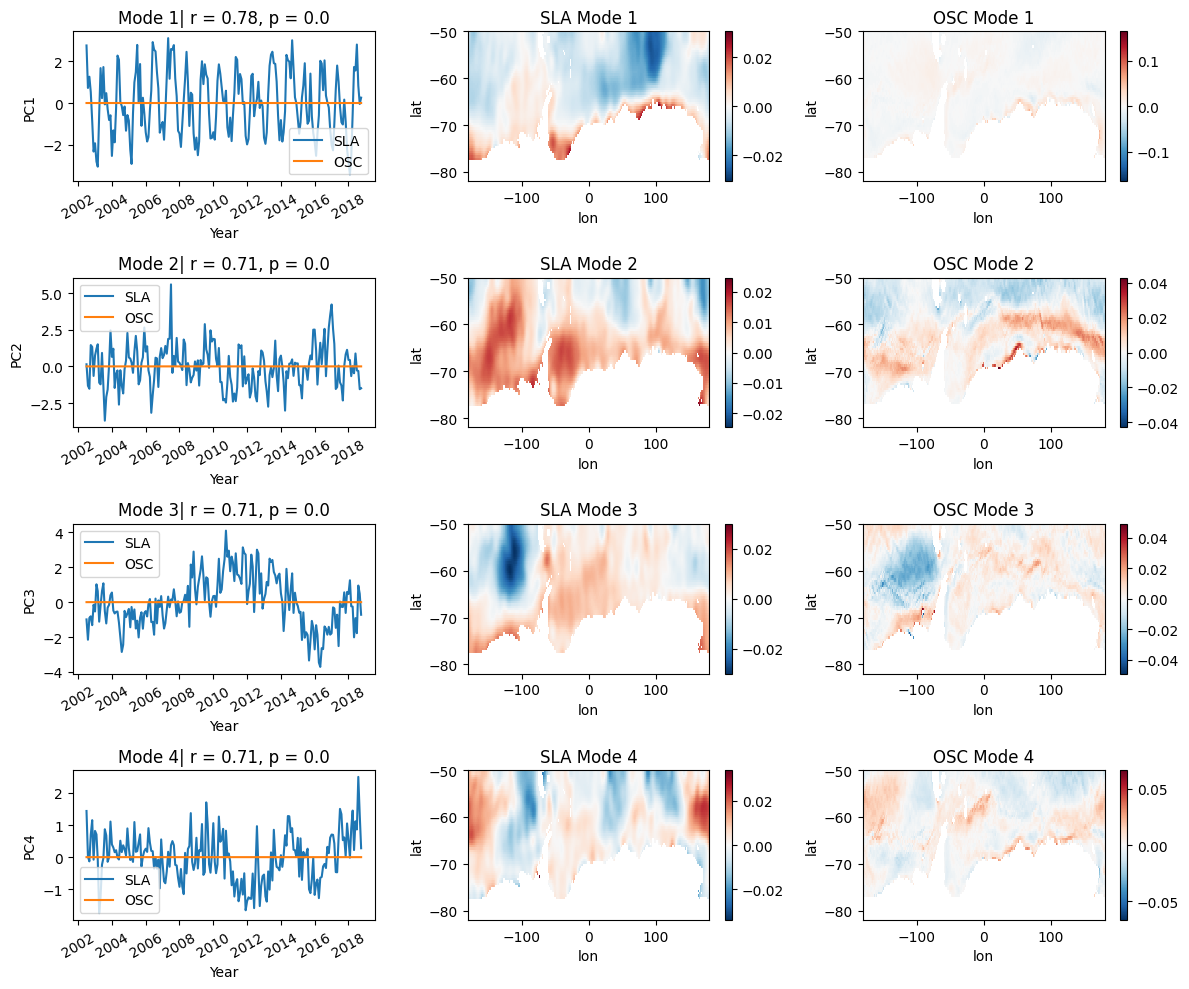

In [107]:
fig = plt.figure(figsize=(12,10))

for i in range(0,4):
    j = 3*i+1

    # --- TIME SERIES ---
    ax = plt.subplot(4,3,j)
    scores1.sel(mode=i+1).plot(label=f'{var_1_name}')
    scores2.sel(mode=i+1).plot(label=f'{var_2_name}')
    ax.set_title(f'Mode {i+1}| r = {r_pears[i]:.2f}, p = {p_pears[i]}')
    ax.set_xlabel('Year')
    ax.set_ylabel(f'PC{i+1}')
    ax.tick_params(axis = 'x', rotation=30)
    ax.legend()
    # plt.title('r = ' + str(r_spear[i]))
    # plt.xlabel('Year'); plt.ylabel('PC'+str(i+1))
    # plt.xticks(rotation=30)
    # plt.legend()

    # --- SPATIAL PATTERNS ---
    # comp1_map = component_to_map(comps1.sel(mode=i+1))
    # comp2_map = component_to_map(comps2.sel(mode=i+1))
    # comp1_map = comps1.sel(mode=i+1).unstack("feature")
    # comp2_map = comps2.sel(mode=i+1).unstack("feature")

    ax2 = plt.subplot(4,3,j+1)
    comps1.sel(mode = i+1).plot(ax = ax2, cmap='RdBu_r')
    ax2.set_title(f'{var_1_name} Mode {i+1}')

    ax3 = plt.subplot(4,3,j+2)
    comps2.sel(mode = i+1).plot(ax = ax3, cmap='RdBu_r')
    ax3.set_title(f'{var_2_name} Mode {i+1}')

    # plt.subplot(4,3,j+1)
    # comp1_map.plot()
    # plt.title('SSH')
    #
    # plt.subplot(4,3,j+2)
    # comp2_map.plot()
    # plt.title('Wind Stress Curl')

fig.tight_layout()
plt.show()
# fig.savefig(save_dir + 'old_ds_to_2018' )

In [108]:
result = model.heterogeneous_patterns()
print(type(result), len(result))
print(type(result[0]))

<class 'tuple'> 2
<class 'tuple'>


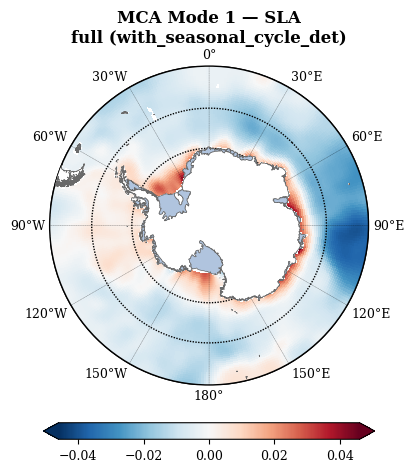

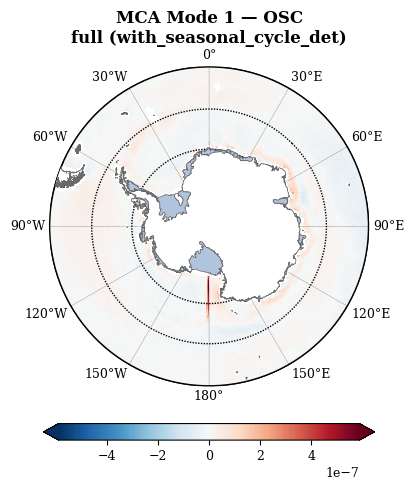

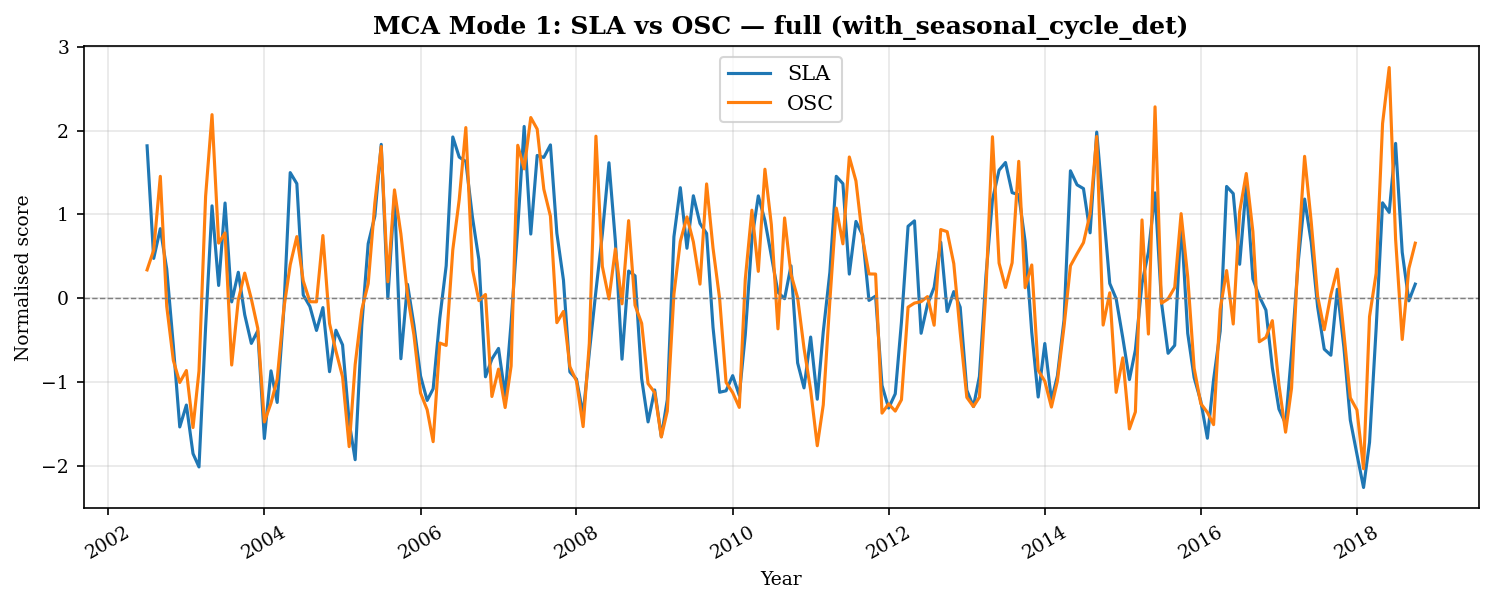

In [117]:
import aux_stereoplot as st
sector_name = 'full'
deseas    = False
detrended = True

suffix  = 'deseas' if deseas else 'with_seasonal_cycle'
suffix += '_det'   if detrended else '_raw'

mode_num = 1

# Get raw components (singular vectors, dimensionless)
comps1, comps2 = model.components()
scores1, scores2 = model.scores()

# Scale spatial patterns by std of the corresponding PC score
# This preserves original units when reconstructed
comp1_m = comps1.sel(mode=mode_num) * scores1.sel(mode=mode_num).std().item()
comp2_m = comps2.sel(mode=mode_num) * scores2.sel(mode=mode_num).std().item()

# Normalise the scores for the time series plot
s1_norm = scores1.sel(mode=mode_num) / scores1.sel(mode=mode_num).std()
s2_norm = scores2.sel(mode=mode_num) / scores2.sel(mode=mode_num).std()

# --- Shared vlims ---
# maxabs = max(
#     np.nanmax(np.abs(comp1_m.values)),
#     np.nanmax(np.abs(comp2_m.values))
# )
# vlims_1 = [-maxabs, maxabs]
# vlims_2 = [-maxabs, maxabs]

# --- Separate vlims for each variable ---
maxabs_1 = float(np.nanmax(np.abs(comp1_m.values)))
maxabs_2 = float(np.nanmax(np.abs(comp2_m.values)))
vlims_1 = [-maxabs_1, maxabs_1]
vlims_2 = [-maxabs_2, maxabs_2]
# vlims_2 = [-1e-7, 1e-7]

# --- Grid + wrap for stereo plotting ---
lons = comp1_m.lon.values
lats = comp1_m.lat.values

llon_w1, llat_w1, comp1_wrapped = st.wrap_lon_for_plot(comp1_m.values, lons, lats)
llon_w2, llat_w2, comp2_wrapped = st.wrap_lon_for_plot(comp2_m.values, lons, lats)

# ============================
# FIGURE 1 — Stereo var_1
# ============================
fig1, ax1, _ = st.spstere_plot(
    llon_w1, llat_w1, comp1_wrapped,
    vlims_1, 'RdBu_r', '', bcolor=None
)
fig1.tight_layout(rect=[0, 0, 1, 0.93])
fig1.suptitle(
    f'MCA Mode {mode_num} — {var_1_name}\n{sector_name} ({suffix})',
    fontsize=12, fontweight='bold'
)

# ============================
# FIGURE 2 — Stereo var_2
# ============================
fig2, ax2, _ = st.spstere_plot(
    llon_w2, llat_w2, comp2_wrapped,
    vlims_2, 'RdBu_r', '', bcolor=None
)
fig2.tight_layout(rect=[0, 0, 1, 0.93])
fig2.suptitle(
    f'MCA Mode {mode_num} — {var_2_name}\n{sector_name} ({suffix})',
    fontsize=12, fontweight='bold'
)

# ============================
# FIGURE 3 — Timeseries
# ============================
# s1_norm = s1 / s1.std()
# s2_norm = s2 / s2.std()

fig3, ax3 = plt.subplots(figsize=(12, 4), dpi=150)
ax3.plot(s1_norm.time, s1_norm, label=var_1_name, linewidth=1.5)
ax3.plot(s2_norm.time, s2_norm, label=var_2_name, linewidth=1.5)
ax3.axhline(0, color='grey', linewidth=0.7, linestyle='--')

ax3.set_xlabel('Year')
ax3.set_ylabel('Normalised score')
ax3.set_title(
    f'MCA Mode {mode_num}: {var_1_name} vs {var_2_name} — {sector_name} ({suffix})',
    fontsize=12, fontweight='bold'
)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=30)

plt.show()


In [110]:
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:',scf)

Cumulative sum of squares: [0.45962517 0.70181007 0.8340032  0.86853595 0.89928348 0.92159496
 0.93608985 0.94590789 0.95370356 0.959387   0.96415749 0.96827081
 0.97200643 0.97517528 0.97787317 0.98021275 0.98206059 0.98381189
 0.98534486 0.9867127  0.98803568 0.9892347 ]
Squared covariance fraction: [0.45962517 0.24218491 0.13219313 0.03453275 0.03074753 0.02231148
 0.01449489 0.00981804 0.00779567 0.00568344 0.00477049 0.00411333
 0.00373561 0.00316885 0.00269789 0.00233958 0.00184784 0.00175131
 0.00153297 0.00136783 0.00132298 0.00119902]


In [111]:
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent =float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i]-cum_sum[i-1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


<class 'numpy.ndarray'>
22
PCA fraction [0.4596251676245303, 0.24218490654910496, 0.13219312609443845, 0.03453275256695487, 0.030747526746707998, 0.022311481209469464, 0.014494887015886304, 0.009818040004796247, 0.007795667339561385, 0.005683444951989802, 0.004770486309610966, 0.004113326729250466, 0.00373561407267331, 0.0031688489072370096, 0.002697891883608805, 0.0023395816038003225, 0.0018478366395195955, 0.0017513064690390934, 0.0015329721669646856, 0.0013678330243791503, 0.0013229826636897979, 0.0011990216102331086]


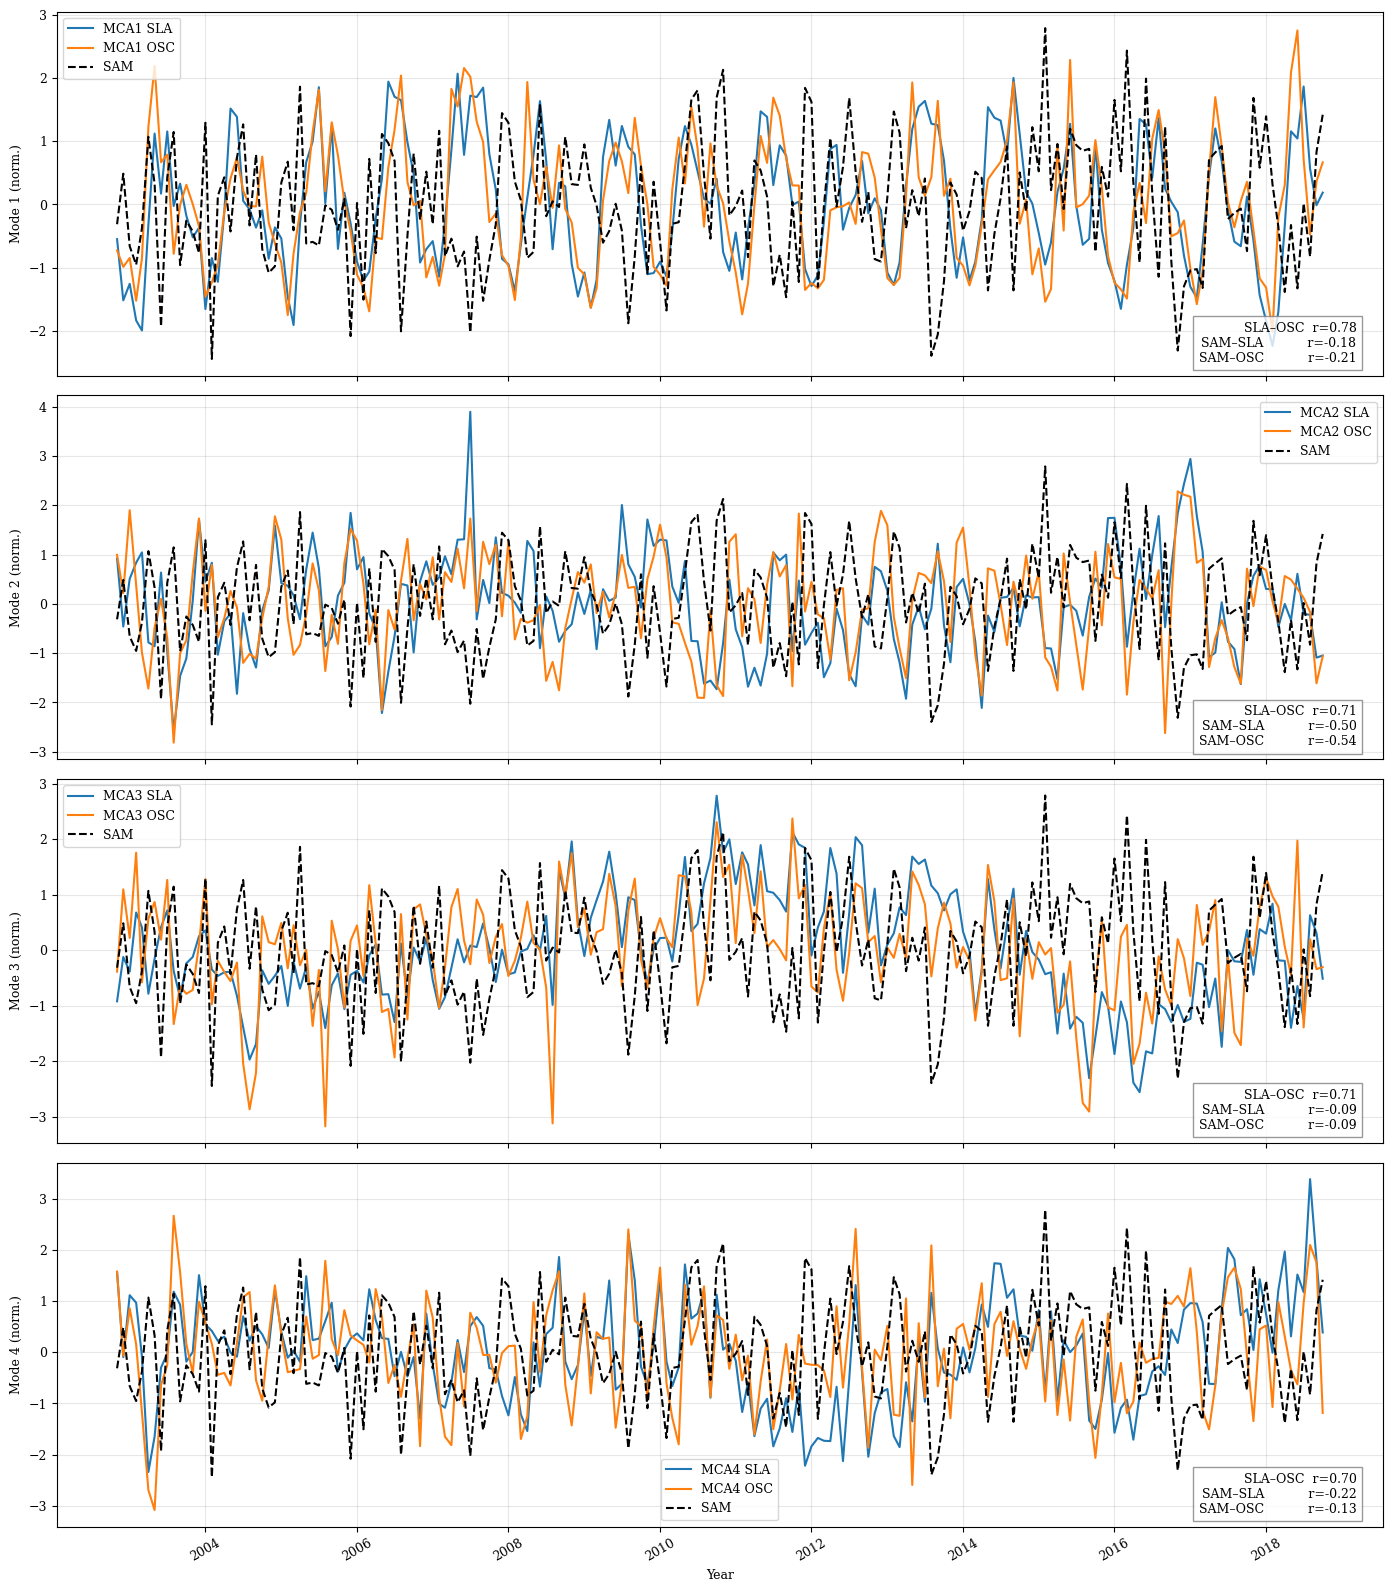

In [112]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
sam_ds  = xr.open_dataset(clim_dir + 'SAM/sam_2000_2024.nc')
sam_da  = sam_ds["SAM"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(sam_da.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

index_da   = sam_da.sel(time=common_time)
index_norm = (index_da - index_da.mean()) / index_da.std()

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n,           label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n,           label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='SAM')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'SAM–{var_1_name}           r={r_i1:.2f}\n'
        f'SAM–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

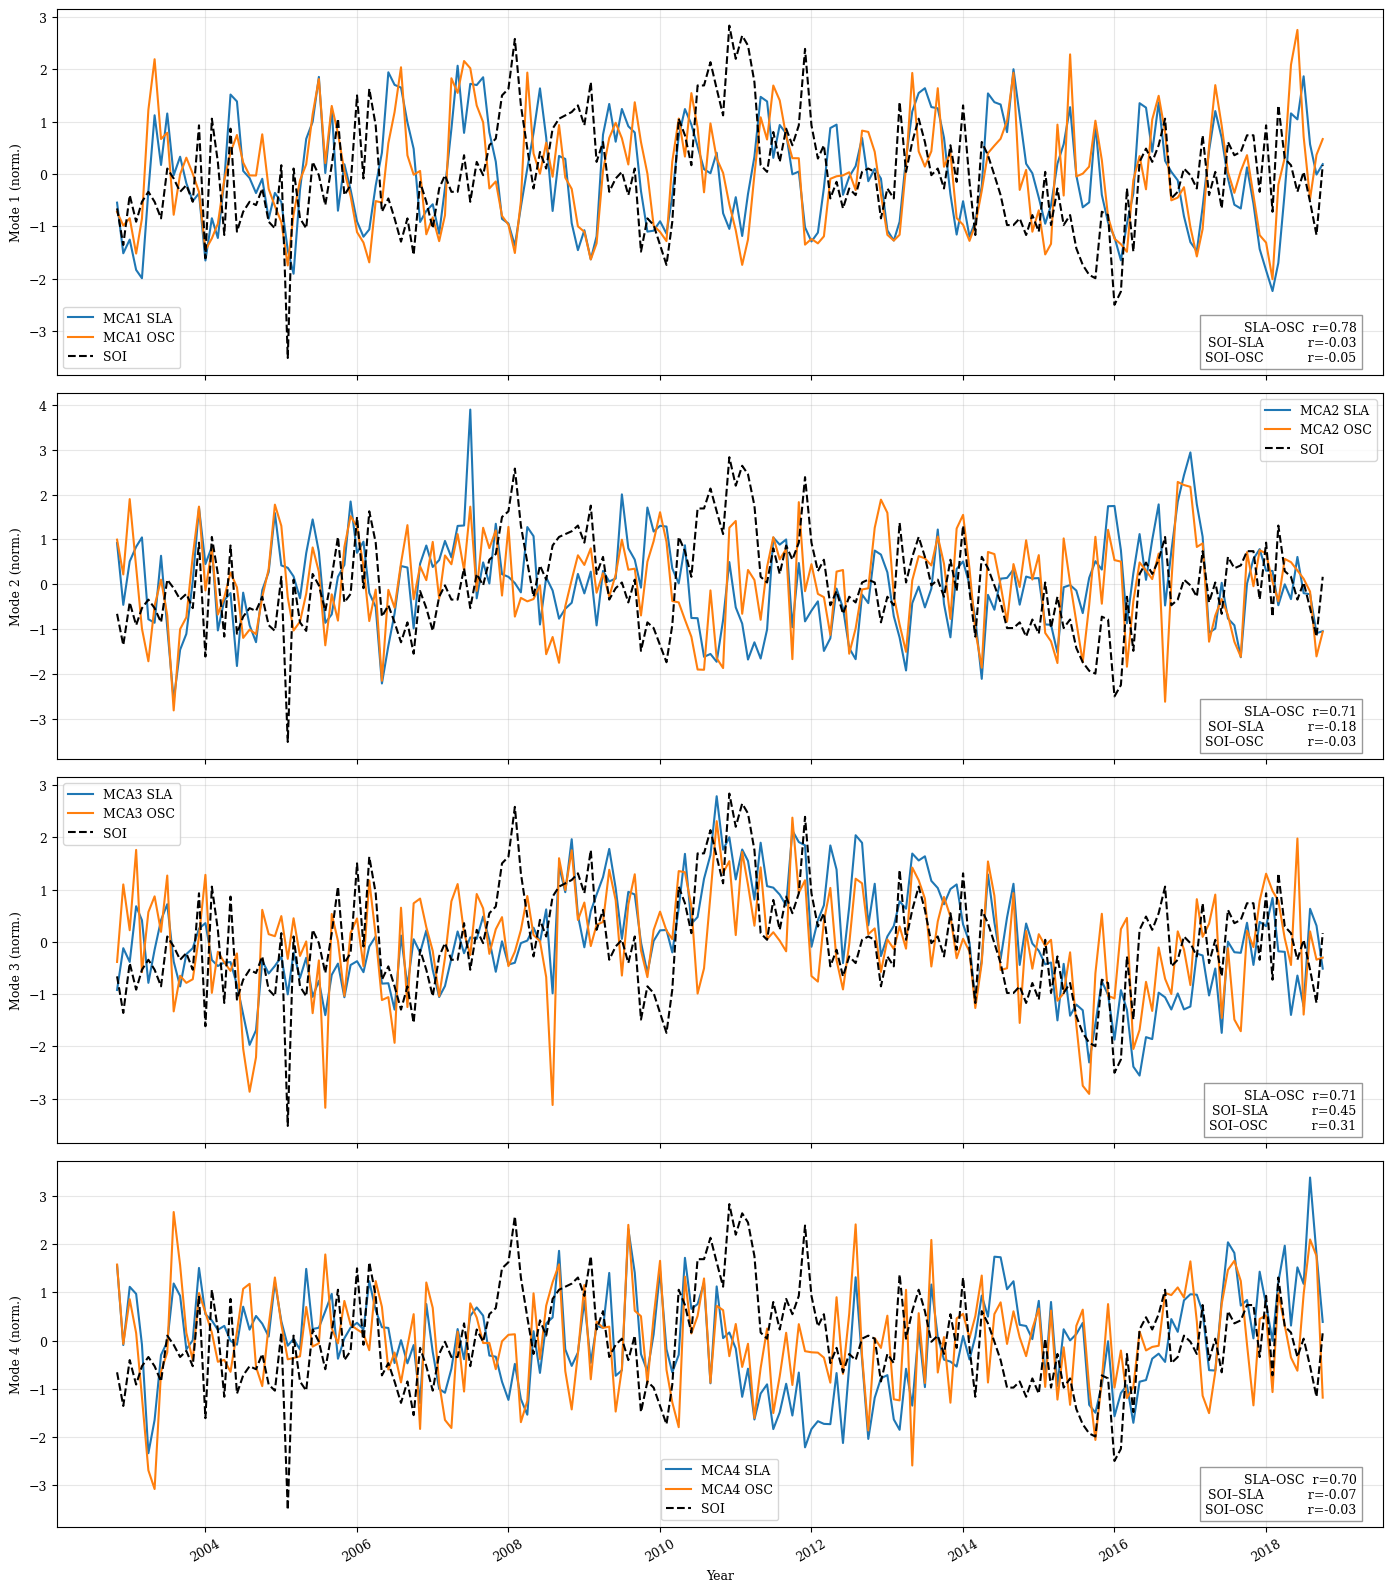

In [113]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
soi_ds  = xr.open_dataset(clim_dir + 'SOI/soi_2000_2024.nc')
soi_da  = soi_ds["SOI"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(soi_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

index_da   = soi_da.sel(time=common_time)
index_norm = (index_da - index_da.mean()) / index_da.std()

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n,           label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n,           label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='SOI')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'SOI–{var_1_name}           r={r_i1:.2f}\n'
        f'SOI–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

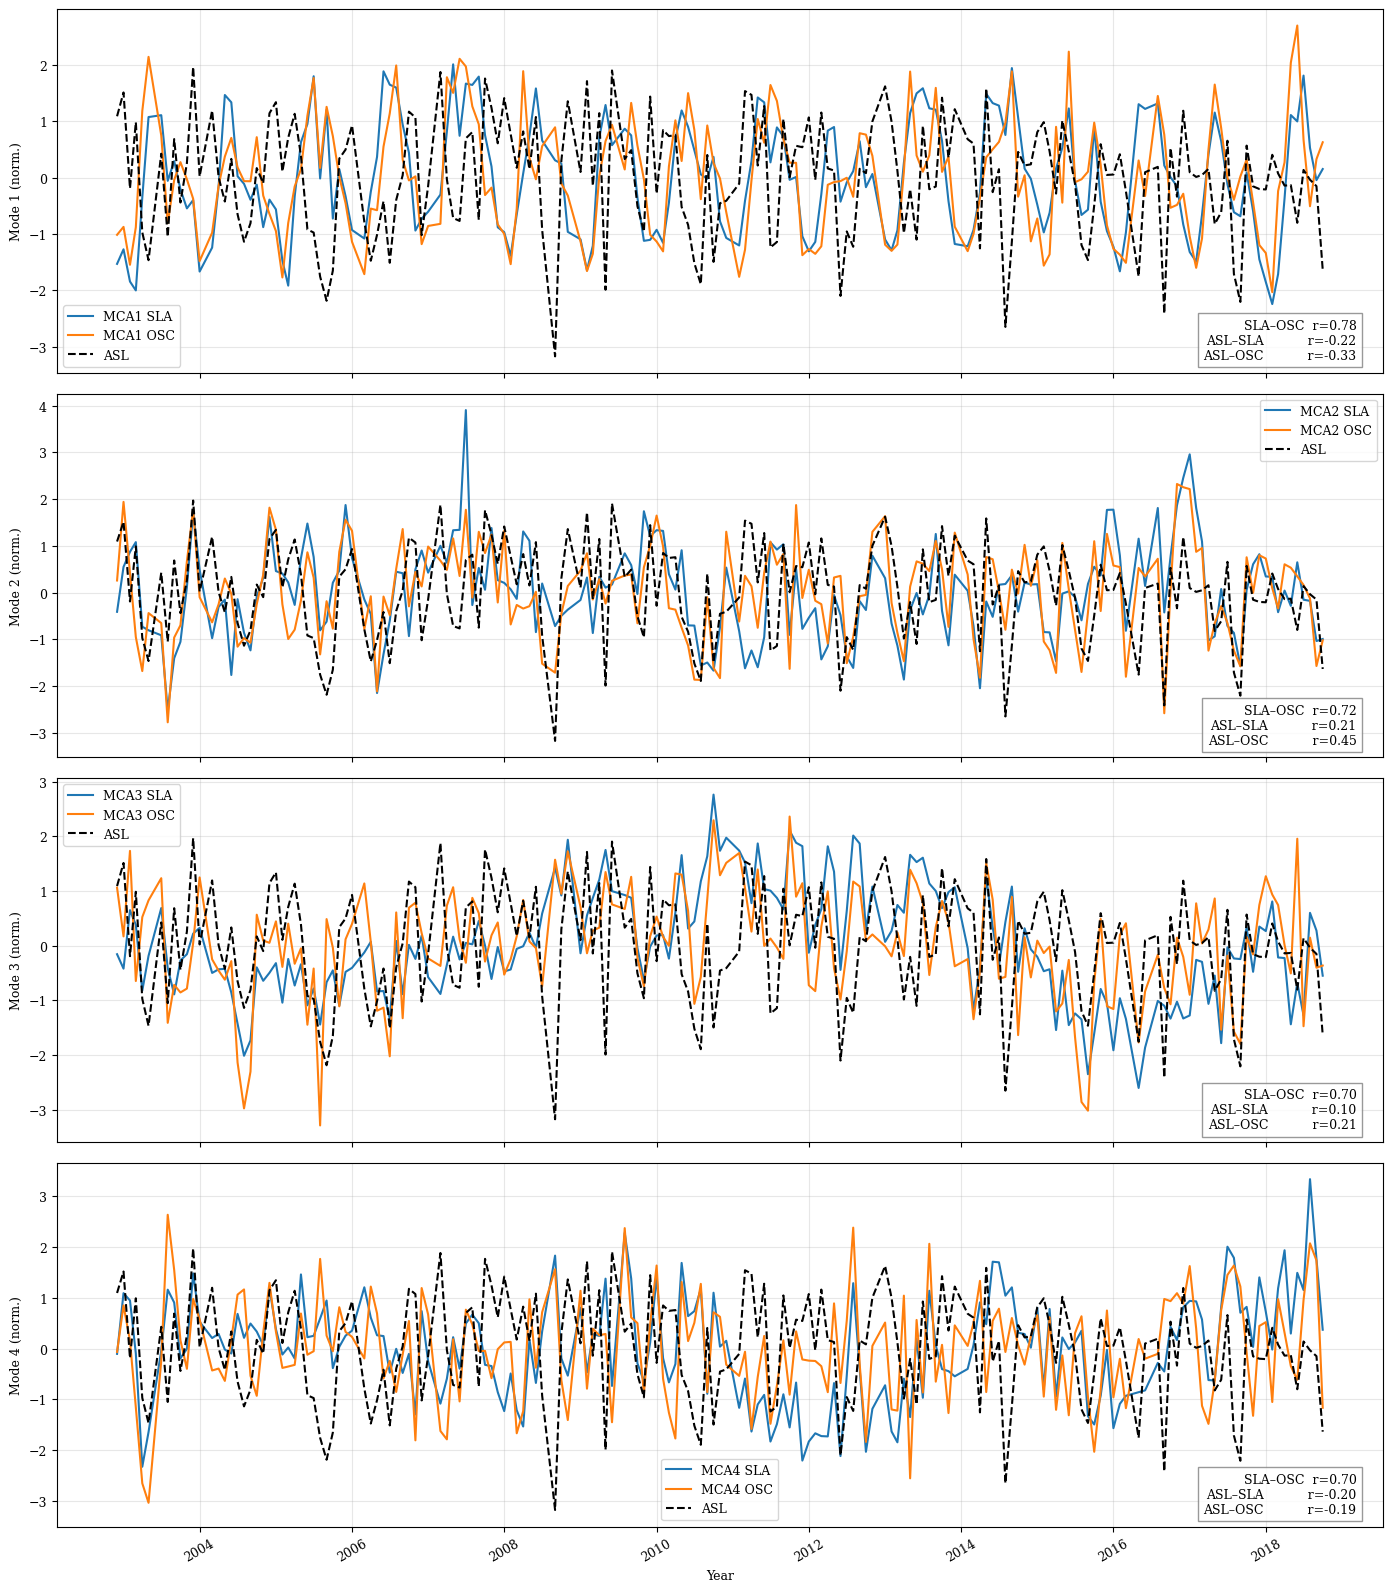

In [114]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align ALS ──────────────────────────────────────────────────────
asl_ds  = xr.open_dataset(clim_dir + 'ASL/ASL_2000_2025_data.nc')
asl_da  = asl_ds["RelCenPres"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(asl_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

index_da   = asl_da.sel(time=common_time)
index_norm = (index_da - index_da.mean()) / index_da.std()

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n,           label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n,           label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='ASL')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'ASL–{var_1_name}           r={r_i1:.2f}\n'
        f'ASL–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

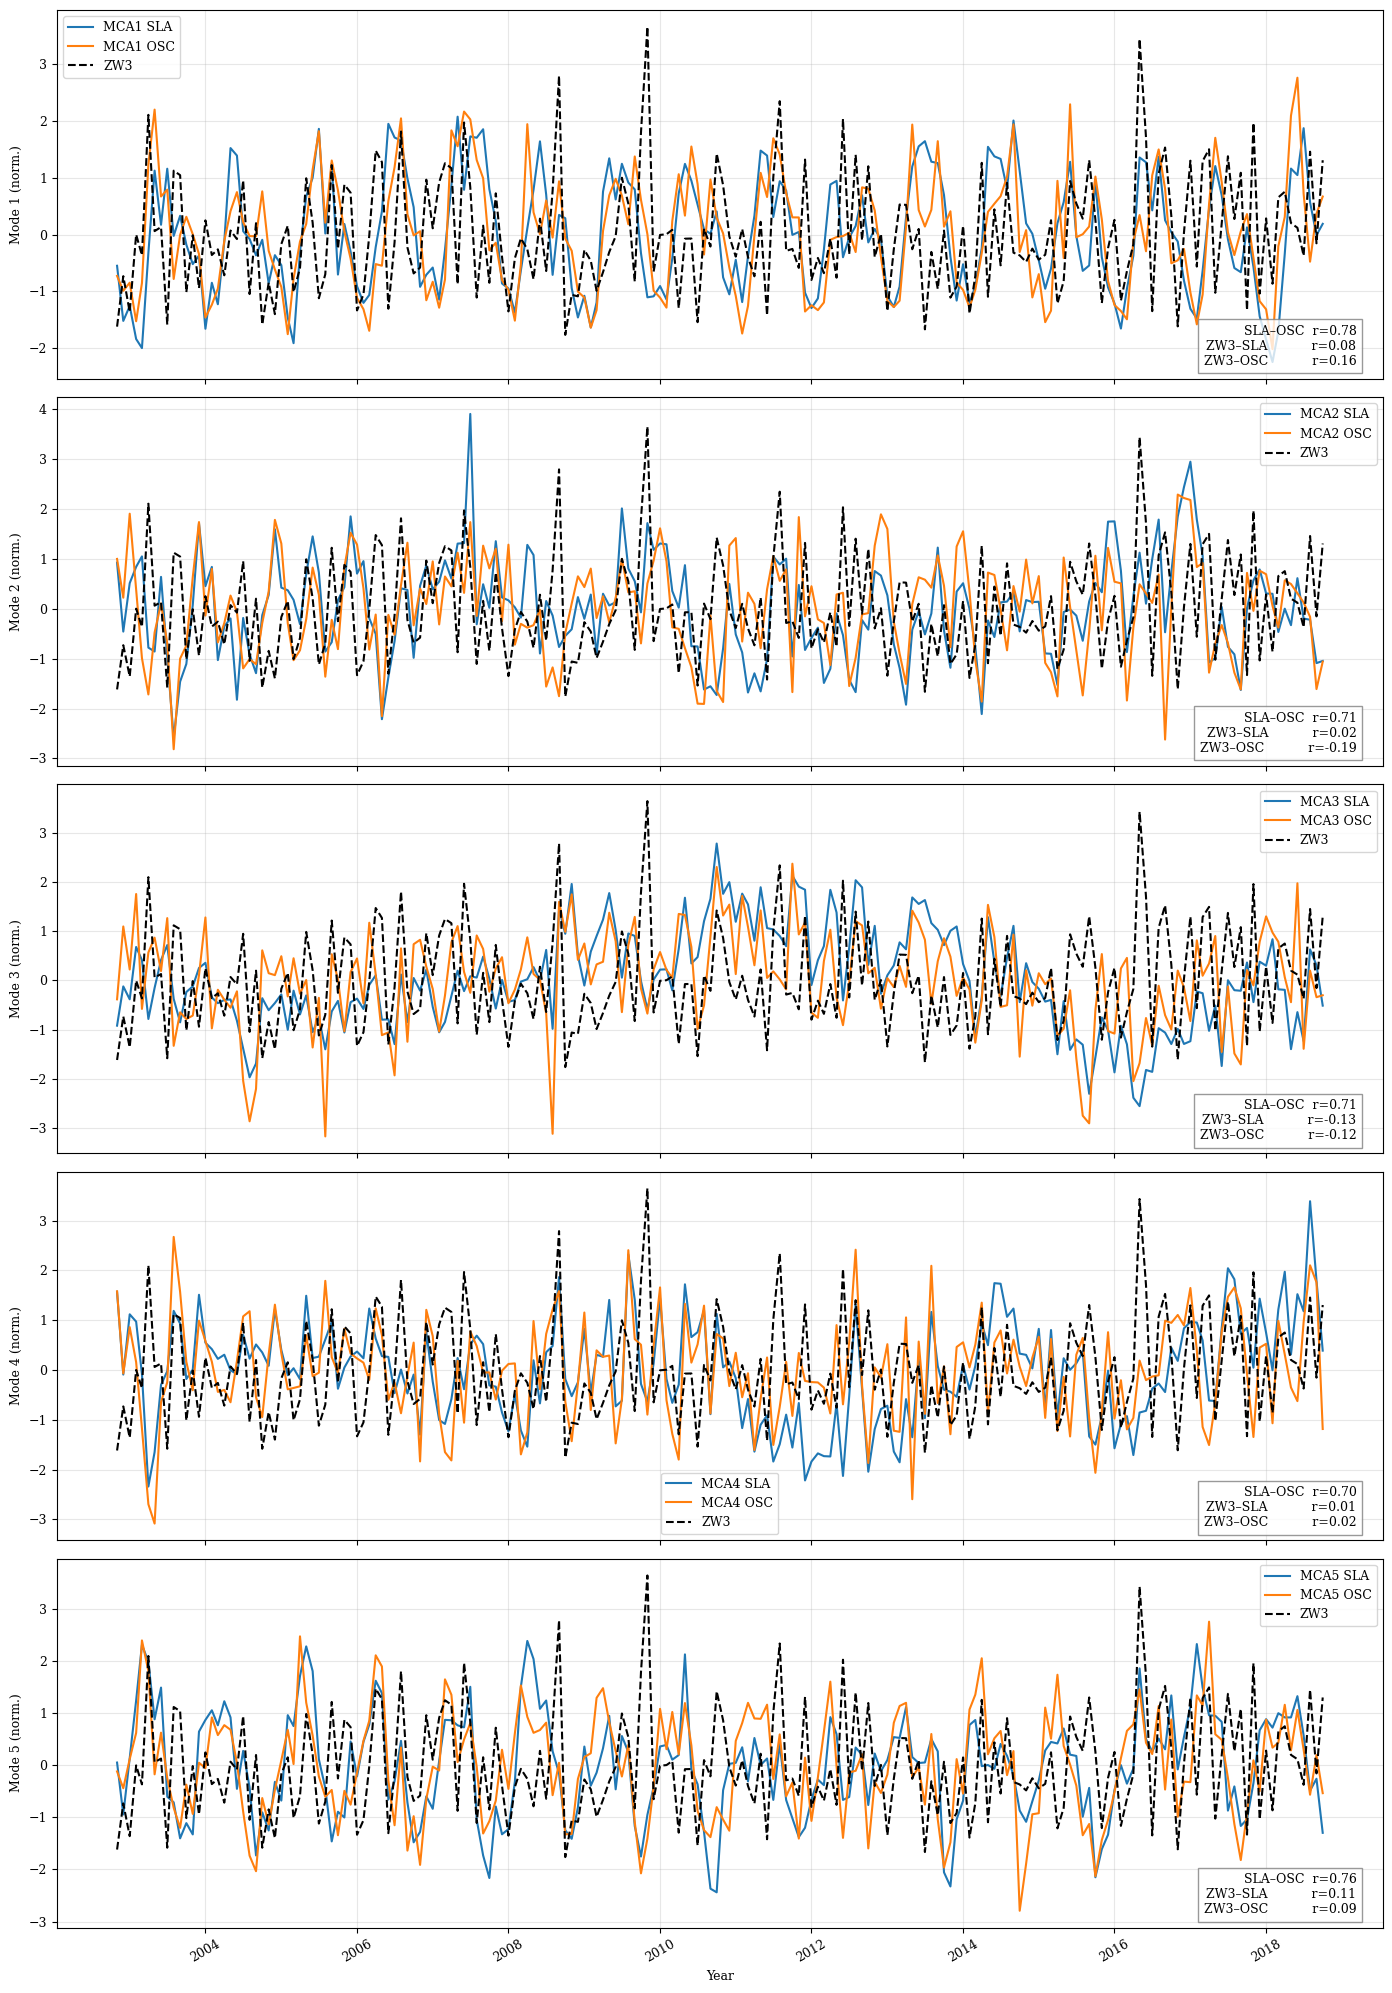

In [115]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
zw3_ds  = xr.open_dataset(clim_dir + 'ZW3/zw3_2000_2024.nc')
zw3_da  = zw3_ds["zw3index_magnitude"] #zw3index_magnitude # zw3index_phase

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(zw3_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

index_da   = zw3_da.sel(time=common_time)
index_norm = (index_da - index_da.mean()) / index_da.std()

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 5
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n,           label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n,           label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='ZW3')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'ZW3–{var_1_name}           r={r_i1:.2f}\n'
        f'ZW3–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [116]:
print(zw3_ds)

<xarray.Dataset> Size: 12kB
Dimensions:             (time: 300)
Coordinates:
  * time                (time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
Data variables:
    zw3index_magnitude  (time) float64 2kB ...
    zw3index_phase      (time) float64 2kB ...
    pc1                 (time) float64 2kB ...
    pc2                 (time) float64 2kB ...
Attributes:
    long_name:  Zonal Wave 3
    units:      dimensionless
    notes:      Created using the ZW3_index.ipynb file, taken from Goyal et a...
